# Lackadaysical Quantum Walks with Noise



This notebook provides the foundational implementation used to generate the results reported in the paper *“Noise-Resilient Spatial Search with Lackadaisical Quantum Walks”* (https://arxiv.org/abs/2508.13462). Its primary purpose is to build intuition and produce exploratory plots. The production code used for the final experiments is more extensively optimized for performance and scalability.



## Simulation code

In [ ]:
import numpy as np
from numpy import sqrt
import matplotlib.pyplot as plt

In [ ]:
#import warnings
#warnings.filterwarnings('error')

In [ ]:
# Define the indices of the coin.
up = 0
down = 1
left = 2
right = 3
stay = 4

In [ ]:
def generate_adjacency(L, bl_prob):
    """Generates an adjacenty matrix with broken links.

    Generates an adjacency matrix for the two-dimensional LxL grid with broken links (or edges).
    The probability of breaking each edge is given by parameter bl_prob. The
    quantum walker can use the output matrix to decide if it can move to a
    certain site or not. If entry (i,j,k,l) is set to True then the shift operator
    is allowed to move the walker from site (i,j) to (k,l) -- even though it doesn't
    have to. If entry (i,j,k,l) is set to False then the shift operator must make sure that
    the walker will not move from site (i,j) to (k,l).

    Args:
        L (int): the grid size
        bl_prob (float): the probability of breaking each edge

    Returns:
        numpy.ndarray: a four-dimensional boolean matrix
    """

    adjacency = np.random.rand(L*L, L*L)
    adjacency[adjacency >= bl_prob] = 1
    adjacency[adjacency < bl_prob] = 0
    adjacency = np.tril(adjacency) + np.triu(adjacency.T, 1)
    adjacency = np.reshape(adjacency,(L,L,L,L))
    return adjacency.astype(bool)

In [ ]:
def grover_coin(psi, L, ell = 0.0):
    """Aplies the Grover coin operator with self-loop.

    Applies the Grover coin operator with self-loop to a state vector corresponding
    to a quantum walk on the LxL grid.

    Args:
        psi (numpy.ndarray): a three-dimensional array (two dimensions for space and the last one for coin)
        L (int): the grid size
        ell (float): the weight of the self-loop

    Returns:
        a three-dimensional array (two dimensions for space and the last one for coin)
    """

    # Allocate temporary space for the state after the Grover coin is applied.
    tmp = np.empty((L, L, 5))

    # Weighted Grover coin.
    for x in range(L):
        for y in range(L):
            # Calculate the average
            bar = (psi[x][y][up] + psi[x][y][down] + psi[x][y][left] + psi[x][y][right] + sqrt(ell)*psi[x][y][stay]) / (4 + ell)

            # Do the inversions.
            tmp[x][y][up] = 2*bar - psi[x][y][up]
            tmp[x][y][down] = 2*bar - psi[x][y][down]
            tmp[x][y][left] = 2*bar - psi[x][y][left]
            tmp[x][y][right] = 2*bar - psi[x][y][right]
            tmp[x][y][stay] = 2*bar*sqrt(ell) - psi[x][y][stay]

    return tmp

In [ ]:
def ff_shift(before, after, L, bl_prob = 0.0):
    """Performs the flip-flop shift operation on a state vector of a
    quantum walk on an LxL grid.

    The shift operation updates the state vector according to the adjacency matrix
    generated with the given grid size and broken link probability.

    Args:
        before (numpy.ndarray): The input state vector before the shift operation.
        after (numpy.ndarray): The output state vector after the shift operation.
        L (int): The grid size.
        bl_prob (float): The probability of breaking each edge. Defaults to 0.0.

    Returns:
        None
    """

    adjacency = generate_adjacency(L, bl_prob)

    for x in range(L):
        for y in range(L):

            if adjacency[x][y][x][(y+1) % L]:
                after[x][y][up] = before[x][(y+1) % L][down]
            else:
                after[x][y][up] = before[x][y][up]

            if adjacency[x][y][x][y-1]:
                after[x][y][down] = before[x][y-1][up]
            else:
                after[x][y][down] = before[x][y][down]

            if adjacency[x][y][x-1][y]:
                after[x][y][left] = before[x-1][y][right]
            else:
                after[x][y][left] = before[x][y][left]

            if adjacency[x][y][(x+1) % L][y]:
                after[x][y][right] = before[(x+1) % L][y][left]
            else:
                after[x][y][right] = before[x][y][right]

            after[x][y][stay] = before[x][y][stay]

In [ ]:
def experiment(L = 16,
               num_steps = 100,
               ell = None,
               bl_prob = 0.0,
               wx = None,
               wy = None,
               save_all_steps = False,
               initial_psi = None,
               shots = 1):
    """Simulates an experiment of a quantum walk on an LxL grid.

    The function performs a simulation of a quantum walk experiment on an LxL grid,
    with options to control various parameters such as the number of steps, self-loop weight,
    broken link probability, marked vertex coordinates, and more.

    Args:
        L (int): The size of the grid. Defaults to 16.
        num_steps (int): The number of steps to simulate. Defaults to 100.
        ell (float): The weight of the self-loop. If None, it is calculated as 4/N. Defaults to None.
        bl_prob (float): The probability of breaking each edge. Defaults to 0.0.
        wx (int): The x-coordinate of the marked vertex. If None, it is set to floor(L/2). Defaults to None.
        wy (int): The y-coordinate of the marked vertex. If None, it is set to floor(L/2). Defaults to None.
        save_all_steps (bool): Whether to save the state at each step. Defaults to False.
        initial_psi (numpy.ndarray): The initial state vector. If None, a default state is used. Defaults to None.
        shots (int): The number of times to repeat the experiment. Defaults to 1.

    Returns:
        Tuple[numpy.ndarray, numpy.ndarray, Union[None, List[numpy.ndarray]]]: A tuple containing three elements.
            - w_probs (numpy.ndarray): The success probabilities for each step, averaged over all shots.
            - w_stds: standard deviation of success probabilities per step.
            - all_steps (Union[None, List[numpy.ndarray]]): If save_all_steps is True, a list of state vectors at each step
              averaged over all shots. Otherwise, None.
    """

    # Calculate the number of vertices.
    N = L*L

    # Calculate the weight of the self-loop.
    if ell is None:
        ell = 4/N   # Tom Wong uses l, but I think it is easily confused with 1 in some fonts.

    # Without loss of generality, let the marked vertex be "in the middle" of the lattice.
    if wx is None:
        wx = L // 2
    if wy is None:
        wy = L // 2

    w_probs = np.zeros(num_steps)
    w_probs_sq = np.zeros(num_steps)  # for std deviation calculation

    if save_all_steps:
        all_steps = [np.zeros((L, L)) for _ in range(num_steps)]
    else:
        all_steps = None

    for _ in range(shots):

        # Define the initial state. The first two indices are the (x,y)
        # coordinate and the last is the coin.
        if initial_psi is None:
            psi = np.tile(np.array([
                1 / sqrt(N * (4 + ell)),
                1 / sqrt(N * (4 + ell)),
                1 / sqrt(N * (4 + ell)),
                1 / sqrt(N * (4 + ell)),
                sqrt(ell) / sqrt(N * (4 + ell))
                ]), (L, L, 1))
        else:
            psi = np.copy(initial_psi)

        # Keep track of the success probability and time.
        last_prob = 0

        # Simulate the quantum walk.
        for t in range(num_steps):

            psi[wx][wy] *= -1  # Oracle query.
            tmp = grover_coin(psi, L, ell)  # Grover coin.
            ff_shift(tmp, psi, L, bl_prob)  # Flip-flop shift.

            np.testing.assert_allclose(np.linalg.norm(psi), 1.0, rtol=1e-7)

            # Save the current success probability for the next iteration.
            last_prob = (psi[wx][wy]**2).sum()
            w_probs[t] += last_prob
            w_probs_sq[t] += last_prob**2

            if save_all_steps:
                all_steps[t] += np.sum(psi**2, axis=2)

    w_probs /= shots
    w_probs_sq /= shots

    var = w_probs_sq - w_probs**2
    var = np.maximum(var, 0)  # replaces negative tiny values with 0
    w_stds = np.sqrt(var)

    if save_all_steps:
        for t in range(num_steps):
            all_steps[t] /= shots

    return w_probs, w_stds, all_steps

</br>
</br>
<b>WARNING:</b> Sections bellow may take a really long time to complete!
</br>
</br>
</br>

## Preliminary experiments

Figure 2 of our paper: Comparison of several cases without broken links, illustrating the isolated effect of self-loops. This essentially reproduces plots from Thomas Wong’s original paper.


In [ ]:
grid_size = 32
N = grid_size * grid_size

In [ ]:
w_probs_A, w_stds_A, _ = experiment(L = grid_size, ell=0.00, bl_prob = 0.0, num_steps = 300, shots = 1, save_all_steps=False)
w_probs_B, w_stds_B,  _ = experiment(L = grid_size, ell=1/N, bl_prob = 0.0, num_steps = 300, shots = 1, save_all_steps=False)
w_probs_C, w_stds_C,  _ = experiment(L = grid_size, ell=4/N, bl_prob = 0.0, num_steps = 300, shots = 1, save_all_steps=False)

In [ ]:
np.testing.assert_array_equal(w_stds_A, np.zeros_like(w_stds_A))
np.testing.assert_array_equal(w_stds_B, np.zeros_like(w_stds_B))
np.testing.assert_array_equal(w_stds_C, np.zeros_like(w_stds_C))

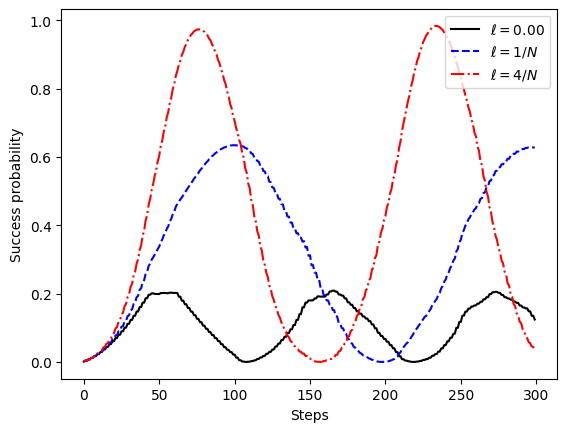

In [ ]:
plt.plot(w_probs_A, 'k-', label=f'$\\ell=0.00$')
plt.plot(w_probs_B, 'b--', label=f'$\\ell=1/N$')
plt.plot(w_probs_C, 'r-.', label=f'$\\ell=4/N$')
plt.xlabel('Steps')
plt.ylabel('Success probability')
plt.legend(loc='upper right')
plt.savefig('prob-vs-steps.png')

Figure 4 of our paper: Comparison of cases without self-loops, illustrating the effect of broken-link decoherence.


In [ ]:
w_probs_A, w_stds_A, _ = experiment(L = grid_size, ell=0.00, bl_prob = 0.0, num_steps = 800, shots = 1, save_all_steps=False)
w_probs_B, w_stds_B, _ = experiment(L = grid_size, ell=0.00, bl_prob = 0.001, num_steps = 800, shots = 50, save_all_steps=False)
w_probs_C, w_stds_C, _ = experiment(L = grid_size, ell=0.00, bl_prob = 0.01, num_steps = 800, shots = 50, save_all_steps=False)

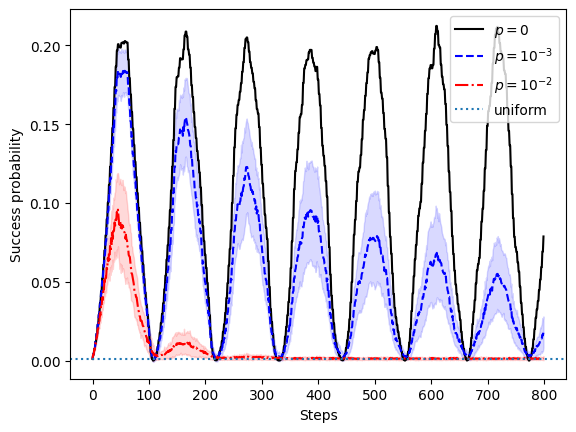

In [ ]:
plt.plot(w_probs_A, 'k-', label='$p=0$')

plt.plot(w_probs_B, 'b--', label='$p=10^{-3}$')
plt.fill_between(range(len(w_probs_B)), w_probs_B - w_stds_B, w_probs_B + w_stds_B, alpha=0.15, color='b')

plt.plot(w_probs_C, 'r-.', label='$p=10^{-2}$')
plt.fill_between(range(len(w_probs_C)), w_probs_C - w_stds_C, w_probs_C + w_stds_C, alpha=0.15, color='r')

plt.axhline(y=1/N, linestyle=':', label='uniform')
plt.xlabel('Steps')
plt.ylabel('Success probability')
plt.legend(loc='upper right')
plt.savefig('succprob-vs-steps-broken-links.png')
plt.show()

Figure 5 of our paper: Comparison of cases with self-loops and broken links, showing that self-loops make the walk more robust.


In [ ]:
grid_size = 32
N = grid_size * grid_size
print(f'Optimal l = {4/N:.2e}')

Optimal l = 3.91e-03


In [ ]:
w_probs_A, w_stds_A, _ = experiment(L = grid_size, ell=0.004, bl_prob = 0.01, num_steps = 1000, shots = 50, save_all_steps=False)
w_probs_B, w_stds_B, _ = experiment(L = grid_size, ell=0.002, bl_prob = 0.01, num_steps = 1000, shots = 50, save_all_steps=False)
w_probs_C, w_stds_C, _ = experiment(L = grid_size, ell=0.000, bl_prob = 0.01, num_steps = 1000, shots = 50, save_all_steps=False)

/tmp/ipython-input-972193353.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


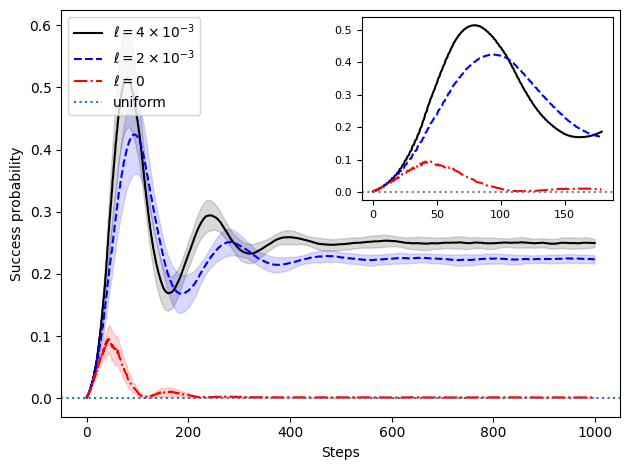

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Main plot
plt.plot(w_probs_A, 'k-', label='$\\ell=4 \\times 10^{-3}$')
plt.fill_between(range(len(w_probs_A)), w_probs_A - w_stds_A, w_probs_A + w_stds_A, alpha=0.15, color='k')

plt.plot(w_probs_B, 'b--', label='$\\ell=2 \\times 10^{-3}$')
plt.fill_between(range(len(w_probs_B)), w_probs_B - w_stds_B, w_probs_B + w_stds_B, alpha=0.15, color='b')

plt.plot(w_probs_C, 'r-.', label='$\\ell=0$')
plt.fill_between(range(len(w_probs_C)), w_probs_C - w_stds_C, w_probs_C + w_stds_C, alpha=0.15, color='r')

plt.axhline(y=1/N, linestyle=':', label='uniform')
plt.xlabel('Steps')
plt.ylabel('Success probability')
plt.legend(loc='upper left')

# Inset axes
ax_inset = inset_axes(plt.gca(), width="45%", height="45%", loc='upper right')
ax_inset.plot(w_probs_A[:180], 'k-', label='$\\ell=4 \\times 10^{-3}$')
ax_inset.plot(w_probs_B[:180], 'b--', label='$\\ell=5 \\times 10^{-3}$')
ax_inset.plot(w_probs_C[:180], 'r-.', label='$\\ell=0$')
ax_inset.axhline(y=1/N, linestyle=':', color='gray')
#ax_inset.set_title('First 100 steps', fontsize=9)
ax_inset.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('prob-vs-steps.png')
plt.show()

In [ ]:
grid_size

16

In [ ]:
w_probs, w_stds, all_steps = experiment(L = grid_size, ell=0.00, bl_prob = 0.0, num_steps = 10000, shots = 1, save_all_steps=True)
mean_distr_noiseless_loopless = np.mean(all_steps, axis=0)

In [ ]:
w_probs, w_stds, all_steps = experiment(L = grid_size, ell=0.01, bl_prob = 0.0, num_steps = 10000, shots = 1, save_all_steps=True)
mean_distr_noiseless_loop = np.mean(all_steps, axis=0)

In [ ]:
w_probs, w_stds, all_steps = experiment(L = grid_size, ell=0.00, bl_prob = 0.01, num_steps = 10000, shots = 20, save_all_steps=True)
mean_distr_noisy_loopless = np.mean(all_steps, axis=0)

In [ ]:
w_probs, w_stds, all_steps = experiment(L = grid_size, ell=0.01, bl_prob = 0.01, num_steps = 10000, shots = 20, save_all_steps=True)
mean_distr_noisy_loop = np.mean(all_steps, axis=0)

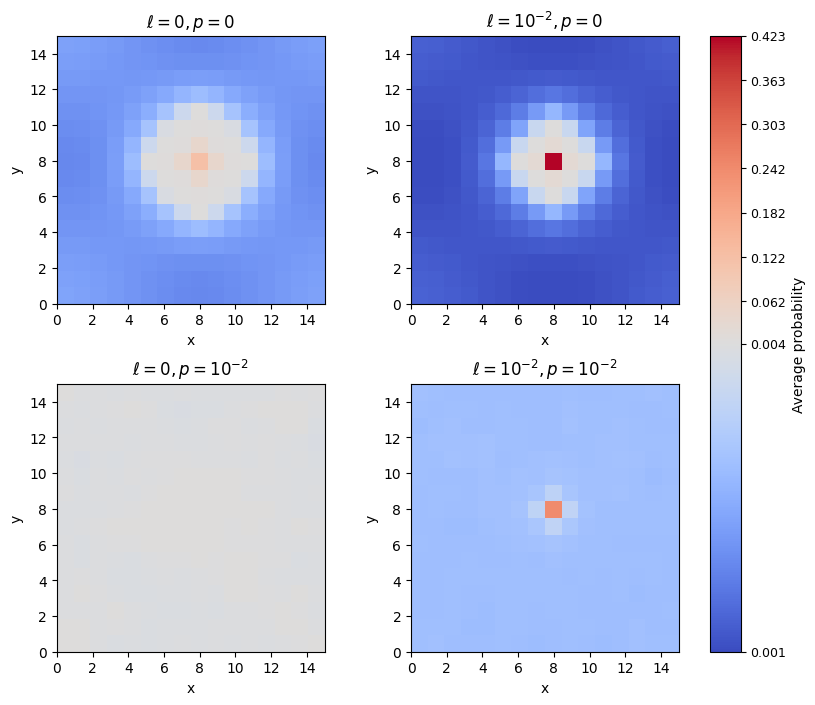

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

distributions = [
    mean_distr_noiseless_loopless,
    mean_distr_noiseless_loop,
    mean_distr_noisy_loopless,
    mean_distr_noisy_loop
]

titles = [
    "$\\ell=0, p=0$",
    "$\\ell=10^{-2}, p=0$",
    "$\\ell=0, p=10^{-2}$",
    "$\\ell=10^{-2}, p=10^{-2}$"
]

# Common color scale
vmin = min(np.min(d) for d in distributions)
vmax = max(np.max(d) for d in distributions)

# Extension to align the axys
Lx, Ly = distributions[0].shape
extent = [0, Lx - 1, 0, Ly - 1]

# Create figure with controlled spacing
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    gridspec_kw={'hspace': 0.3, 'wspace': 0.0}  # vertical & horizontal space
)

# Deixar axes como lista simples para facilitar o loop
axes = axes.ravel()

# Choose one norm below, comment the others:

# # 1. Power-law gamma < 1 enhances small values
# norm = colors.PowerNorm(gamma=0.35, vmin=vmin, vmax=vmax)

# 2. TwoSlopeNorm for highlighting deviations from vcenter
N = distributions[0].size # Uniform distribution reference
vcenter = 1 / N  # central reference value
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

for ax, data, title in zip(axes, distributions, titles):
    im = ax.imshow(
        data,
        #cmap='viridis',
        cmap='coolwarm',  # works better with TwoSlopeNorm
        #vmin=vmin, vmax=vmax,
        norm=norm,
        extent=extent,
        origin='lower',
        aspect='equal'
    )
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    ax.set_xticks(np.arange(0, Lx, 2))
    ax.set_yticks(np.arange(0, Ly, 2))


cbar = fig.colorbar(
    im, ax=axes,
    fraction=0.046, pad=0.04
)
cbar.set_label('Average probability', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ticks = np.linspace(vmin, vmax, 8)

# Ensure uniform probability is included
if vcenter not in ticks:
    ticks = np.sort(np.append(ticks, vcenter))

cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.3f}" for t in ticks])

#plt.tight_layout()
plt.savefig('prob-heatmaps.png')
plt.show()


## Further experiments

In [ ]:
from tqdm import tqdm
# this package add a progress bar which helps a lot in the visualization of the remaining time for simulation
# I highly recommend installing it (with pip install tqdm)

In [ ]:
results_partialA = {}
results_partialB = {}
results_partialC = {}
results_partialD = {}
for ell in tqdm(np.linspace(0.0, 0.25, 151)):
    #print(f'ell = {ell:e}')
    w_probsA, w_stdsA, _ = experiment(L = 16, ell=ell, bl_prob = 0.0, num_steps = 60, shots = 1)
    w_probsB, w_stdsB, _ = experiment(L = 16, ell=ell, bl_prob = 0.001, num_steps = 60, shots = 40)
    w_probsC, w_stdsC, _ = experiment(L = 16, ell=ell, bl_prob = 0.005, num_steps = 60, shots = 40)
    w_probsD, w_stdsD, _ = experiment(L = 16, ell=ell, bl_prob = 0.01, num_steps = 60, shots = 40)

    results_partialA[ell] = np.max(w_probsA)
    results_partialB[ell] = np.max(w_probsB)
    results_partialC[ell] = np.max(w_probsC)
    results_partialD[ell] = np.max(w_probsD)
max_keyA = max(results_partialA, key=results_partialA.get)
max_keyB = max(results_partialB, key=results_partialB.get)
max_keyC = max(results_partialC, key=results_partialC.get)
max_keyD = max(results_partialD, key=results_partialD.get)

100%|██████████| 151/151 [1:48:10<00:00, 42.98s/it]


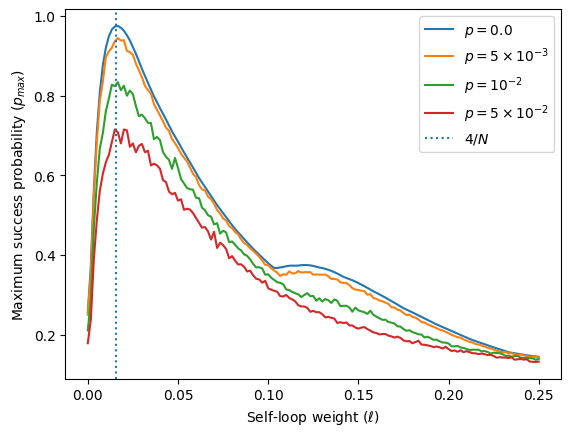

In [ ]:
plt.plot(*zip(*sorted(results_partialA.items())), '-', label='$p=0.0$')
plt.plot(*zip(*sorted(results_partialB.items())), '-', label='$p=5 \\times 10^{-3}$')
plt.plot(*zip(*sorted(results_partialC.items())), '-', label='$p=10^{-2}$')
plt.plot(*zip(*sorted(results_partialD.items())), '-', label='$p=5 \\times 10^{-2}$')
plt.xlabel('Self-loop weight ($\\ell$)')
plt.ylabel('Maximum success probability ($p_{max}$)')
plt.axvline(x=4/(16**2), linestyle=':', label='$4/N$')
#plt.axvline(x=max_keyA, linestyle='--', label='optimal $\\ell$ (noisy case)')
plt.legend(loc='upper right')
plt.savefig('maxprob-vs-loop.png')
plt.show()